# Unsupervised Learning — K-Means, DBSCAN, PCA, t-SNE

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/ml-mastery/blob/main/02_ml_concepts/unsupervised.ipynb)

---

## Table of Contents
1. [Concept Overview](#1-concept-overview)
2. [K-Means Clustering](#2-k-means-clustering)
   - 2.1 Algorithm and Math
   - 2.2 Cost Function (Inertia)
   - 2.3 K-Means++ Initialization
   - 2.4 Choosing K — Elbow and Silhouette
3. [DBSCAN](#3-dbscan)
   - 3.1 Algorithm and Math
   - 3.2 Core, Border, and Noise Points
   - 3.3 DBSCAN vs K-Means
4. [PCA — Principal Component Analysis](#4-pca)
   - 4.1 Covariance Matrix and Eigenvectors
   - 4.2 Full Derivation
   - 4.3 Explained Variance
5. [t-SNE](#5-t-sne)
   - 5.1 Math Intuition
   - 5.2 t-SNE vs PCA
6. [Code from Scratch](#6-code-from-scratch)
7. [Sklearn Implementation](#7-sklearn-implementation)
8. [Common Mistakes](#8-common-mistakes)
9. [Exercises](#9-exercises)


## 1. Concept Overview

**Unsupervised learning** finds structure in data without labels. The four most important techniques in ML practice are:

| Algorithm | Task | Key idea |
|---|---|---|
| **K-Means** | Clustering | Assign points to K clusters by minimizing within-cluster variance |
| **DBSCAN** | Clustering | Find dense regions separated by sparse regions, handles noise |
| **PCA** | Dimensionality reduction | Project to directions of maximum variance |
| **t-SNE** | Visualization | Preserve local neighborhood structure in 2D/3D |

**When to use unsupervised learning:**
- No labels available (or labels are expensive to obtain)
- Exploratory data analysis — understand data structure before modeling
- Feature engineering — reduce dimensions, remove noise
- Anomaly detection — outliers don't fit any cluster
- Preprocessing — PCA before KNN or SVM can dramatically improve performance


## 2. K-Means Clustering

### 2.1 Algorithm and Math

K-Means partitions $m$ points into $K$ clusters by minimizing within-cluster sum of squared distances.

**Algorithm (Lloyd's algorithm):**

1. **Initialize:** Choose $K$ centroids $\mu_1, \mu_2, \dots, \mu_K$ (randomly or via K-Means++)
2. **Assignment step:** Assign each point $\mathbf{x}_i$ to the nearest centroid:
$$z_i = \arg\min_k \|\mathbf{x}_i - \mu_k\|^2$$
3. **Update step:** Move each centroid to the mean of its assigned points:
$$\mu_k = \frac{1}{|C_k|} \sum_{i \in C_k} \mathbf{x}_i$$
4. **Repeat** steps 2–3 until assignments stop changing (convergence)

**Convergence:** The cost function (inertia) is non-increasing at every step — guaranteed to converge, but not necessarily to the global optimum.

---

### 2.2 Cost Function — Inertia (Within-Cluster Sum of Squares)

$$J = \sum_{k=1}^{K} \sum_{i \in C_k} \|\mathbf{x}_i - \mu_k\|^2$$

- Each assignment step minimizes $J$ over assignments $z_i$ (holding centroids fixed)
- Each update step minimizes $J$ over centroids $\mu_k$ (holding assignments fixed)
- Both steps decrease (or maintain) $J$ — coordinate descent on a non-convex objective

**Why non-convex?** Different initializations can lead to different local minima. Sklearn runs K-Means multiple times (`n_init=10`) and keeps the best result.

---

### 2.3 K-Means++ Initialization

Random initialization often leads to poor local minima. K-Means++ chooses better starting centroids:

1. Choose the first centroid $\mu_1$ uniformly at random
2. For each subsequent centroid $\mu_k$: choose point $\mathbf{x}$ with probability proportional to:
$$P(\mathbf{x}) = \frac{D(\mathbf{x})^2}{\sum_{\mathbf{x}'} D(\mathbf{x}')^2}$$
where $D(\mathbf{x})$ is the distance from $\mathbf{x}$ to the nearest already-chosen centroid

This spreads initial centroids far apart, reducing the chance of poor local minima. K-Means++ is the default in sklearn.

---

### 2.4 Choosing K — Elbow Method and Silhouette Score

**Elbow method:** Plot inertia vs $K$. The 'elbow' point where inertia stops decreasing rapidly suggests the optimal $K$.

**Silhouette score:** For each point $i$:
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

where:
- $a(i)$ = mean distance from $i$ to all other points in its cluster (cohesion)
- $b(i)$ = mean distance from $i$ to all points in the nearest other cluster (separation)

Range: $s(i) \in [-1, 1]$. Higher is better. $s \approx 1$ means well-clustered, $s \approx 0$ means on cluster boundary, $s < 0$ means possibly misclassified.


## 3. DBSCAN

### 3.1 Algorithm and Math

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) finds clusters as connected regions of high density separated by low-density regions.

**Two hyperparameters:**
- $\epsilon$ (eps): radius of neighborhood around a point
- `min_samples`: minimum number of points to form a dense region

**Neighborhood of a point:**
$$N_\epsilon(\mathbf{x}) = \{\mathbf{x}' : d(\mathbf{x}, \mathbf{x}') \leq \epsilon\}$$

---

### 3.2 Core, Border, and Noise Points

Every point is classified as one of:

| Type | Definition |
|---|---|
| **Core point** | $|N_\epsilon(\mathbf{x})| \geq$ `min_samples` — has enough neighbors |
| **Border point** | Not a core point, but within $\epsilon$ of a core point |
| **Noise point** | Not a core point, not within $\epsilon$ of any core point (outlier) |

**Cluster formation:**
1. Start from an unvisited core point — create a new cluster
2. Expand by adding all density-reachable points (core neighbors and their core neighbors)
3. Border points get assigned to the cluster but do not expand it
4. Noise points (label = -1) are not assigned to any cluster

**Density-reachability:** $\mathbf{x}$ is density-reachable from $\mathbf{y}$ if there is a chain of core points $p_1, p_2, \dots, p_n$ where $p_1 = \mathbf{y}$, $p_n = \mathbf{x}$, and each $p_{i+1} \in N_\epsilon(p_i)$.

---

### 3.3 DBSCAN vs K-Means

| | K-Means | DBSCAN |
|---|---|---|
| Cluster shape | Convex, spherical | Arbitrary shape |
| Number of clusters | Must specify $K$ | Determined automatically |
| Outliers | All points assigned | Noise points labeled -1 |
| Scalability | $O(nKd)$ per iter | $O(n \log n)$ with index |
| Varying density | Struggles | Struggles (single $\epsilon$) |


## 4. PCA — Principal Component Analysis

### 4.1 What PCA Does

PCA finds a new coordinate system where:
- The first axis (PC1) points in the direction of maximum variance in the data
- The second axis (PC2) is orthogonal to PC1 and points in the direction of next maximum variance
- And so on for PC3, PC4, ...

By keeping only the top $k$ principal components, we compress the data from $d$ dimensions to $k$ while retaining as much variance as possible.

---

### 4.2 Full Derivation

**Step 1 — Center the data:**

$$\tilde{X} = X - \bar{X}$$

**Step 2 — Compute the covariance matrix:**

$$\Sigma = \frac{1}{m-1} \tilde{X}^T \tilde{X} \quad \in \mathbb{R}^{d \times d}$$

Entry $\Sigma_{ij}$ = covariance between feature $i$ and feature $j$. Diagonal entries are variances. Off-diagonal entries measure linear relationships.

**Step 3 — Eigendecomposition of $\Sigma$:**

$$\Sigma = V \Lambda V^T$$

where $V = [\mathbf{v}_1, \mathbf{v}_2, \dots, \mathbf{v}_d]$ are the **eigenvectors** (principal components — directions in feature space) and $\Lambda = \text{diag}(\lambda_1, \lambda_2, \dots, \lambda_d)$ are the **eigenvalues** ($\lambda_1 \geq \lambda_2 \geq \dots$).

**Why eigenvectors?** The eigenvectors of $\Sigma$ are the directions that maximize variance. The variance along eigenvector $\mathbf{v}_k$ is exactly $\lambda_k$.

**Step 4 — Project the data:**

$$Z = \tilde{X} V_k$$

where $V_k$ contains the top $k$ eigenvectors. $Z$ has shape $(m, k)$.

**Alternative: SVD.** In practice sklearn uses SVD instead of eigendecomposition for numerical stability:

$$\tilde{X} = U S V^T$$

The columns of $V$ are the principal components. The singular values $S$ relate to eigenvalues: $\lambda_k = s_k^2 / (m-1)$.

---

### 4.3 Explained Variance Ratio

The proportion of total variance explained by principal component $k$:

$$\text{EVR}_k = \frac{\lambda_k}{\sum_{j=1}^{d} \lambda_j}$$

**Cumulative explained variance:** $\sum_{k=1}^{K} \text{EVR}_k$ — choose $K$ such that this reaches a threshold (typically 95%).


## 5. t-SNE

### 5.1 Math Intuition

t-SNE (t-distributed Stochastic Neighbor Embedding) creates a 2D/3D map that preserves the **local neighborhood structure** of high-dimensional data.

**Step 1 — High-dimensional similarities.** For each pair $(i, j)$, define the probability that point $i$ would pick $j$ as its neighbor using a Gaussian kernel:

$$p_{j|i} = \frac{\exp(-\|\mathbf{x}_i - \mathbf{x}_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|\mathbf{x}_i - \mathbf{x}_k\|^2 / 2\sigma_i^2)}$$

Symmetrized: $p_{ij} = \frac{p_{j|i} + p_{i|j}}{2m}$

**Step 2 — Low-dimensional similarities.** In the 2D map, define similarities using a **Student t-distribution with 1 degree of freedom** (heavier tails than Gaussian):

$$q_{ij} = \frac{(1 + \|\mathbf{y}_i - \mathbf{y}_j\|^2)^{-1}}{\sum_{k \neq l}(1 + \|\mathbf{y}_k - \mathbf{y}_l\|^2)^{-1}}$$

**Step 3 — Minimize KL divergence** between the two distributions:

$$\text{KL}(P \| Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

This is minimized via gradient descent on the positions $\mathbf{y}_i$.

**Why t-distribution?** The heavy tails of the t-distribution allow moderate distances in high-dimensional space to become large distances in 2D — this prevents the 'crowding problem' where all points collapse to the center.

---

### 5.2 t-SNE vs PCA

| | PCA | t-SNE |
|---|---|---|
| Type | Linear | Non-linear |
| Preserves | Global variance | Local neighborhoods |
| Deterministic | Yes | No (random init) |
| Speed | Fast $O(nd^2)$ | Slow $O(n^2)$ |
| Reproducible | Yes | Only with fixed seed |
| Use for | Feature extraction, preprocessing | Visualization only |
| Distances meaningful | Yes | No — only cluster structure matters |

**Important:** t-SNE output should never be used for downstream ML tasks — it is purely a visualization tool. Distances and cluster sizes in t-SNE plots are not meaningful.


## 6. Code from Scratch

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)


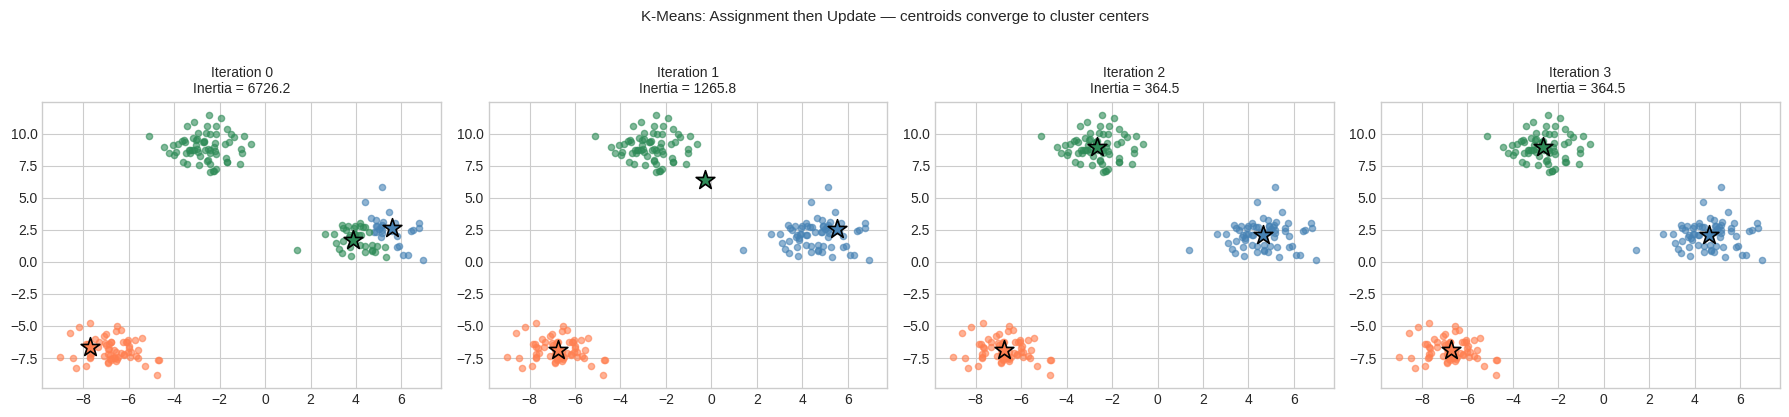

In [2]:
# ── K-Means Visualization: assignment and update steps ───────────────────
from sklearn.datasets import make_blobs

X_km, _ = make_blobs(n_samples=200, centers=3, cluster_std=1.0,
                      random_state=42)

# Manual K-Means to show iterations
K = 3
centroids = X_km[rng.choice(len(X_km), K, replace=False)].copy()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
colors = ['steelblue', 'coral', 'seagreen']

for step, ax in enumerate(axes):
    # Assignment
    dists  = np.array([np.linalg.norm(X_km - c, axis=1) for c in centroids])
    labels = dists.argmin(axis=0)

    for k in range(K):
        ax.scatter(X_km[labels==k, 0], X_km[labels==k, 1],
                   c=colors[k], s=20, alpha=0.6)
        ax.scatter(*centroids[k], c=colors[k], s=200, marker='*',
                   edgecolors='black', linewidth=1.2, zorder=5)

    ax.set_title(f'Iteration {step}\nInertia = {sum(dists[labels[i], i]**2 for i in range(len(X_km))):.1f}',
                 fontsize=10)

    # Update centroids
    for k in range(K):
        if (labels==k).any():
            centroids[k] = X_km[labels==k].mean(axis=0)

plt.suptitle('K-Means: Assignment then Update — centroids converge to cluster centers',
             fontsize=11, y=1.03)
plt.tight_layout()
plt.show()


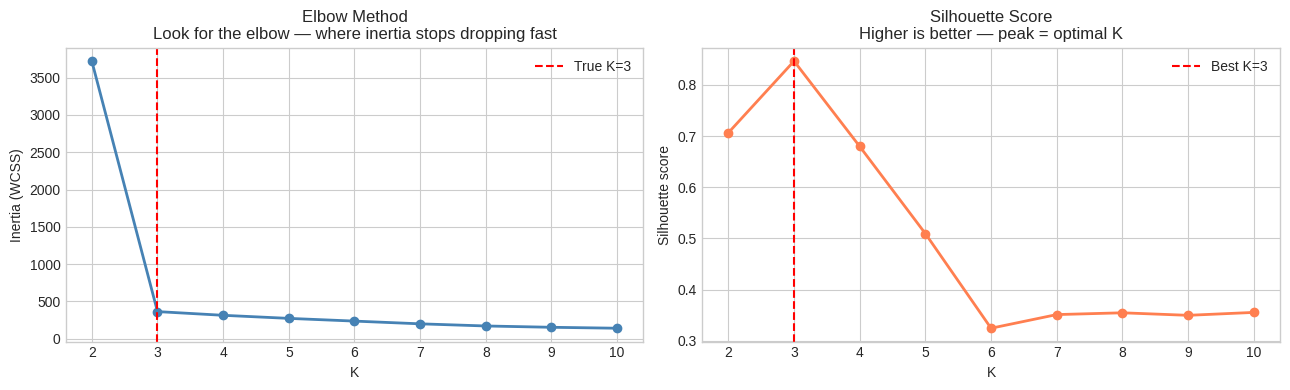

In [3]:
# ── Elbow and Silhouette for choosing K ──────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 11)
inertias, sil_scores = [], []

for K in K_range:
    km = KMeans(n_clusters=K, random_state=42, n_init=10)
    labels = km.fit_predict(X_km)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_km, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_range), inertias, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method\nLook for the elbow — where inertia stops dropping fast')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia (WCSS)')
axes[0].axvline(3, color='red', linestyle='--', linewidth=1.5, label='True K=3')
axes[0].legend()

axes[1].plot(list(K_range), sil_scores, 'o-', color='coral', linewidth=2)
best_K = list(K_range)[np.argmax(sil_scores)]
axes[1].axvline(best_K, color='red', linestyle='--', linewidth=1.5,
                label=f'Best K={best_K}')
axes[1].set_title('Silhouette Score\nHigher is better — peak = optimal K')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette score')
axes[1].legend()

plt.tight_layout()
plt.show()


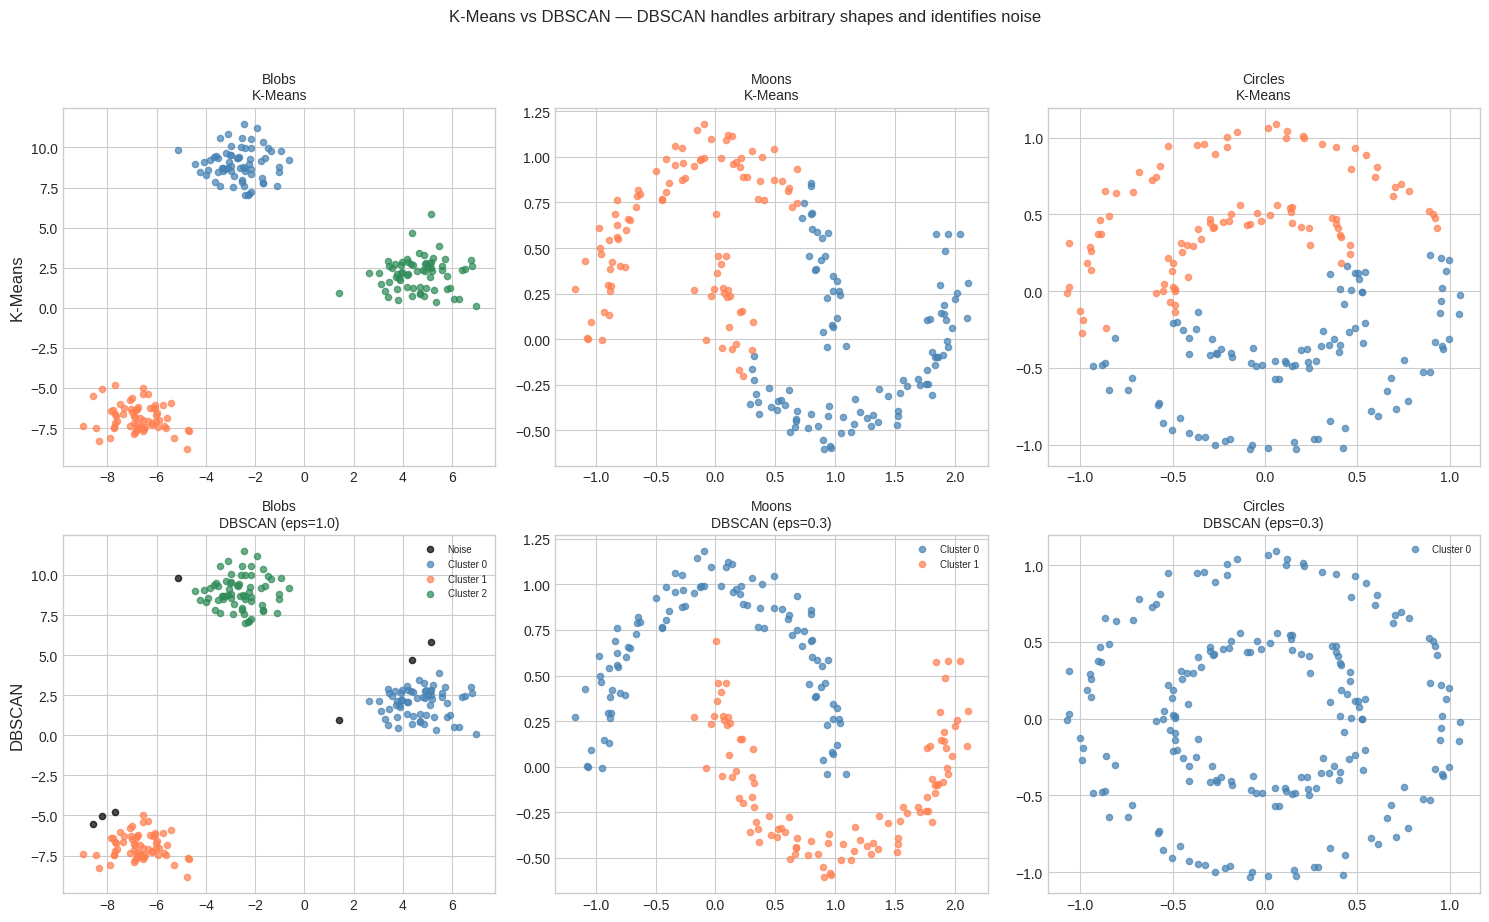

In [4]:
# ── DBSCAN: core, border, noise — and comparison with K-Means on shapes ──
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons, make_circles

datasets = [
    (make_blobs(n_samples=200, centers=3, random_state=42)[0], 'Blobs'),
    (make_moons(n_samples=200, noise=0.08, random_state=42)[0], 'Moons'),
    (make_circles(n_samples=200, noise=0.05, factor=0.5, random_state=42)[0], 'Circles'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
cmap_list = ['steelblue', 'coral', 'seagreen', 'purple', 'orange']

for col, (X_d, name) in enumerate(datasets):
    # K-Means row
    km_d = KMeans(n_clusters=2 if col > 0 else 3, random_state=42, n_init=10)
    lbl_km = km_d.fit_predict(X_d)
    for k in np.unique(lbl_km):
        axes[0, col].scatter(X_d[lbl_km==k,0], X_d[lbl_km==k,1],
                              c=cmap_list[k], s=20, alpha=0.7)
    axes[0, col].set_title(f'{name}\nK-Means', fontsize=10)

    # DBSCAN row
    eps = 0.3 if col > 0 else 1.0
    db  = DBSCAN(eps=eps, min_samples=5)
    lbl_db = db.fit_predict(X_d)
    unique_labels = np.unique(lbl_db)
    for k in unique_labels:
        mask = lbl_db == k
        color = 'black' if k == -1 else cmap_list[k % len(cmap_list)]
        label_str = 'Noise' if k == -1 else f'Cluster {k}'
        axes[1, col].scatter(X_d[mask,0], X_d[mask,1],
                              c=color, s=20, alpha=0.7, label=label_str)
    axes[1, col].set_title(f'{name}\nDBSCAN (eps={eps})', fontsize=10)
    axes[1, col].legend(fontsize=7)

axes[0, 0].set_ylabel('K-Means', fontsize=12)
axes[1, 0].set_ylabel('DBSCAN', fontsize=12)
plt.suptitle('K-Means vs DBSCAN — DBSCAN handles arbitrary shapes and identifies noise',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


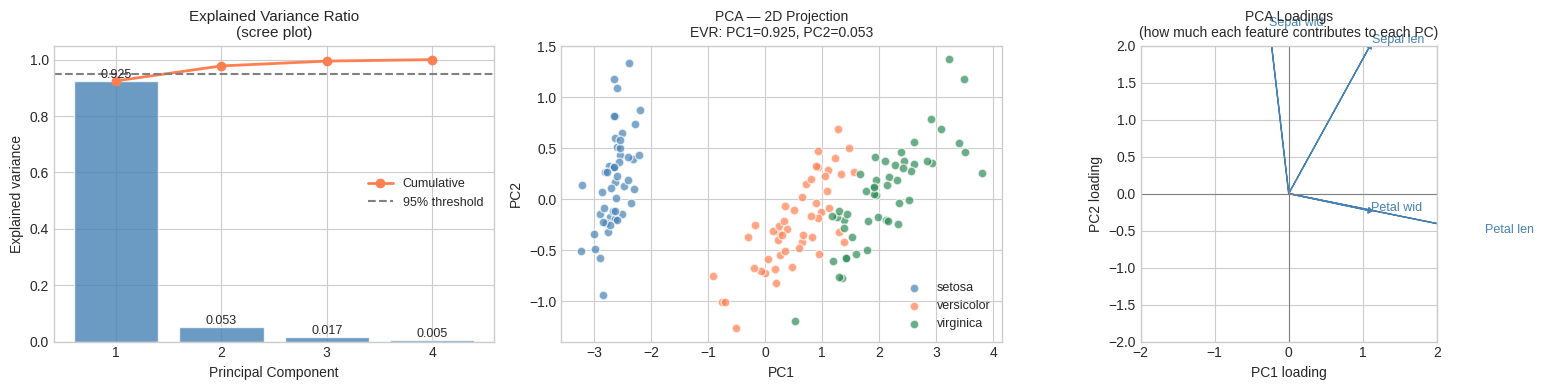

In [5]:
# ── PCA: explained variance and 2D projection ────────────────────────────
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

iris = load_iris()
X_pca, y_pca = iris.data, iris.target

# Full PCA to see explained variance
pca_full = PCA()
pca_full.fit(X_pca)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Scree plot
axes[0].bar(range(1, 5), pca_full.explained_variance_ratio_,
            color='steelblue', alpha=0.8, edgecolor='white')
axes[0].plot(range(1, 5), np.cumsum(pca_full.explained_variance_ratio_),
             'o-', color='coral', linewidth=2, label='Cumulative')
axes[0].axhline(0.95, color='gray', linestyle='--', linewidth=1.5, label='95% threshold')
axes[0].set_title('Explained Variance Ratio\n(scree plot)', fontsize=11)
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Explained variance')
axes[0].set_xticks(range(1, 5))
axes[0].legend(fontsize=9)

for i, evr in enumerate(pca_full.explained_variance_ratio_):
    axes[0].text(i+1, evr+0.01, f'{evr:.3f}', ha='center', fontsize=9)

# 2D projection
pca_2d = PCA(n_components=2)
X_2d   = pca_2d.fit_transform(X_pca)
colors = ['steelblue', 'coral', 'seagreen']
for cls, color, name in zip([0,1,2], colors, iris.target_names):
    axes[1].scatter(X_2d[y_pca==cls,0], X_2d[y_pca==cls,1],
                    c=color, s=40, alpha=0.7, edgecolors='white', label=name)
axes[1].set_title(f'PCA — 2D Projection\n'
                  f'EVR: PC1={pca_2d.explained_variance_ratio_[0]:.3f}, '
                  f'PC2={pca_2d.explained_variance_ratio_[1]:.3f}', fontsize=10)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=9)

# Principal component loadings (feature contributions)
loadings = pca_2d.components_.T
feat_names = ['Sepal len', 'Sepal wid', 'Petal len', 'Petal wid']
for i, (feat, load) in enumerate(zip(feat_names, loadings)):
    axes[2].arrow(0, 0, load[0]*3, load[1]*3,
                  head_width=0.08, head_length=0.05, fc='steelblue', ec='steelblue')
    axes[2].text(load[0]*3.1, load[1]*3.1, feat, fontsize=9, color='steelblue')
axes[2].set_xlim(-2, 2); axes[2].set_ylim(-2, 2)
axes[2].axhline(0, color='gray', linewidth=0.8)
axes[2].axvline(0, color='gray', linewidth=0.8)
axes[2].set_title('PCA Loadings\n(how much each feature contributes to each PC)', fontsize=10)
axes[2].set_xlabel('PC1 loading'); axes[2].set_ylabel('PC2 loading')
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipykernel_19860/2320217168.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap10 = plt.cm.get_cmap('tab10', 10)


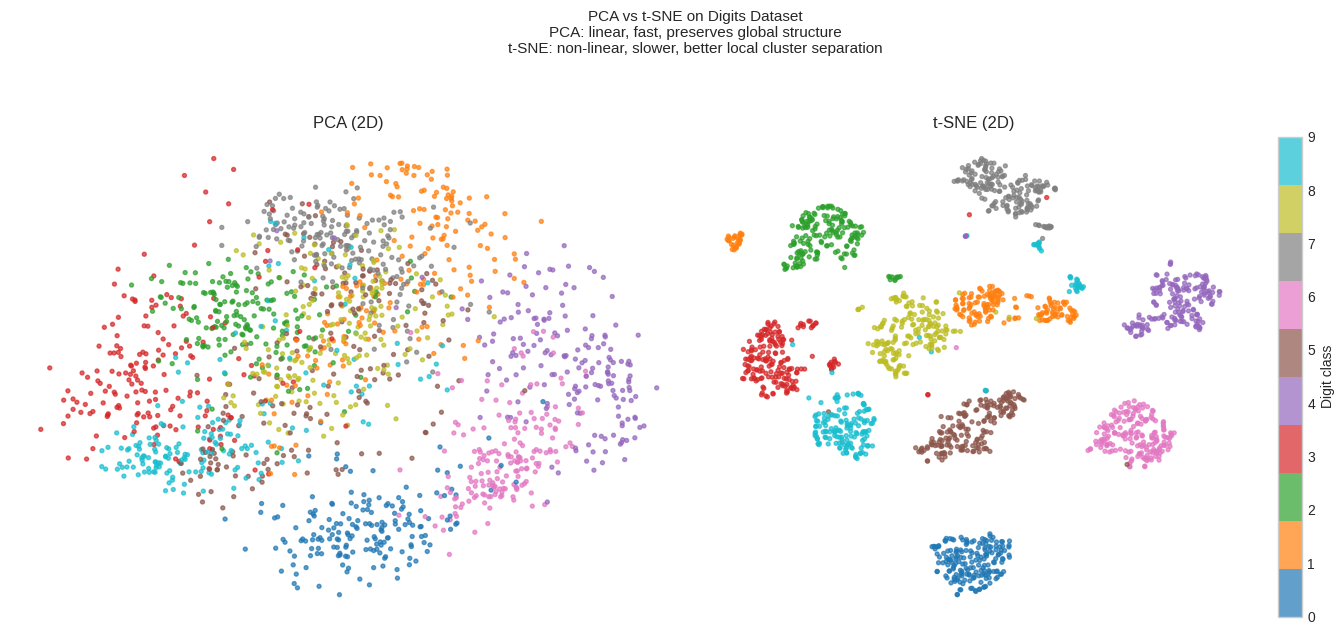

In [6]:
# ── t-SNE vs PCA on digits dataset ───────────────────────────────────────
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits

digits = load_digits()
X_dg, y_dg = digits.data, digits.target

# PCA first (speeds up t-SNE and reduces noise)
X_pca50 = PCA(n_components=50, random_state=42).fit_transform(X_dg)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_pca50)

# Also PCA 2D
X_pca2  = PCA(n_components=2).fit_transform(X_dg)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cmap10 = plt.cm.get_cmap('tab10', 10)

for ax, X_2, title in zip(axes, [X_pca2, X_tsne], ['PCA (2D)', 't-SNE (2D)']):
    sc = ax.scatter(X_2[:,0], X_2[:,1], c=y_dg, cmap='tab10',
                    s=8, alpha=0.7)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.colorbar(sc, ax=axes[1], label='Digit class')
plt.suptitle('PCA vs t-SNE on Digits Dataset\n'
             'PCA: linear, fast, preserves global structure\n'
             't-SNE: non-linear, slower, better local cluster separation',
             fontsize=11, y=1.05)
plt.tight_layout()
plt.show()


## 6. Code from Scratch — K-Means and PCA

In [7]:
class KMeansScratch:
    # K-Means clustering via Lloyd's algorithm.
    # Minimizes: J = sum_k sum_{i in C_k} ||x_i - mu_k||^2

    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4,
                 init='kmeans++', random_state=42):
        self.K           = n_clusters
        self.max_iter    = max_iter
        self.tol         = tol
        self.init        = init
        self.rng         = np.random.default_rng(random_state)
        self.centroids_  = None
        self.labels_     = None
        self.inertia_    = None

    def _init_centroids_pp(self, X):
        # K-Means++ initialization
        idx = self.rng.integers(0, len(X))
        centroids = [X[idx]]
        for _ in range(self.K - 1):
            dists  = np.array([min(np.linalg.norm(x - c)**2
                                   for c in centroids) for x in X])
            probs  = dists / dists.sum()
            idx    = self.rng.choice(len(X), p=probs)
            centroids.append(X[idx])
        return np.array(centroids)

    def fit(self, X):
        if self.init == 'kmeans++':
            self.centroids_ = self._init_centroids_pp(X)
        else:
            idx = self.rng.choice(len(X), self.K, replace=False)
            self.centroids_ = X[idx].copy()

        for _ in range(self.max_iter):
            # Assignment step
            dists  = np.array([np.linalg.norm(X - c, axis=1)
                               for c in self.centroids_])  # (K, m)
            labels = dists.argmin(axis=0)                  # (m,)

            # Update step
            new_centroids = np.array([
                X[labels == k].mean(axis=0) if (labels == k).any()
                else self.centroids_[k]
                for k in range(self.K)
            ])

            # Check convergence
            shift = np.linalg.norm(new_centroids - self.centroids_)
            self.centroids_ = new_centroids
            self.labels_    = labels
            if shift < self.tol:
                break

        # Compute inertia
        self.inertia_ = sum(
            np.linalg.norm(X[labels==k] - self.centroids_[k])**2
            for k in range(self.K) if (labels==k).any()
        )
        return self

    def predict(self, X):
        dists = np.array([np.linalg.norm(X - c, axis=1)
                          for c in self.centroids_])
        return dists.argmin(axis=0)


K-Means Scratch — Inertia: 566.86
Sklearn K-Means — Inertia: 566.86


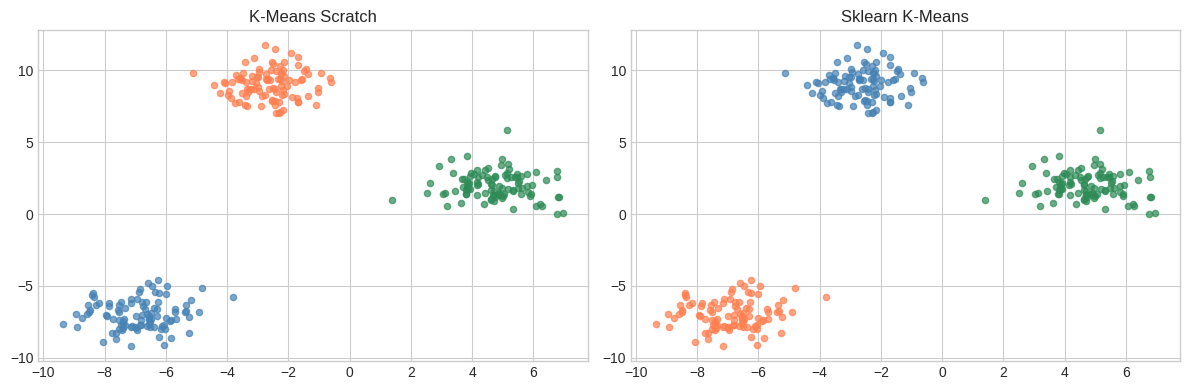

In [8]:
X_test, y_true = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

km_sc = KMeansScratch(n_clusters=3, init='kmeans++', random_state=42)
km_sc.fit(X_test)

print(f'K-Means Scratch — Inertia: {km_sc.inertia_:.2f}')

km_sk = KMeans(n_clusters=3, random_state=42, n_init=1)
km_sk.fit(X_test)
print(f'Sklearn K-Means — Inertia: {km_sk.inertia_:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['steelblue', 'coral', 'seagreen']
for ax, labels, title in zip(axes, [km_sc.labels_, km_sk.labels_],
                              ['K-Means Scratch', 'Sklearn K-Means']):
    for k, c in enumerate(colors):
        ax.scatter(X_test[labels==k,0], X_test[labels==k,1],
                   c=c, s=20, alpha=0.7)
    ax.set_title(title)
plt.tight_layout()
plt.show()


In [9]:
class PCAScratch:
    # PCA from scratch using eigendecomposition of the covariance matrix.
    # Steps: center -> covariance -> eigendecompose -> project

    def __init__(self, n_components=2):
        self.n_components = n_components
        self.components_              = None   # eigenvectors (n_comp, d)
        self.explained_variance_      = None   # eigenvalues
        self.explained_variance_ratio_= None
        self.mean_                    = None

    def fit(self, X):
        m, d         = X.shape
        self.mean_   = X.mean(axis=0)
        X_centered   = X - self.mean_

        # Covariance matrix
        cov = (X_centered.T @ X_centered) / (m - 1)   # (d, d)

        # Eigendecomposition
        eigenvalues, eigenvectors = np.linalg.eigh(cov)

        # Sort descending (eigh returns ascending)
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues  = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]             # (d, d)

        # Keep top n_components
        self.components_               = eigenvectors[:, :self.n_components].T
        self.explained_variance_       = eigenvalues[:self.n_components]
        self.explained_variance_ratio_ = eigenvalues[:self.n_components] / eigenvalues.sum()
        return self

    def transform(self, X):
        return (X - self.mean_) @ self.components_.T

    def fit_transform(self, X):
        return self.fit(X).transform(X)


In [10]:
iris = load_iris()
X_ir, y_ir = iris.data, iris.target

pca_sc = PCAScratch(n_components=2)
X_sc   = pca_sc.fit_transform(X_ir)

pca_sk = PCA(n_components=2)
X_sk   = pca_sk.fit_transform(X_ir)

print('PCA Scratch explained variance ratio:', pca_sc.explained_variance_ratio_.round(4))
print('Sklearn PCA explained variance ratio:', pca_sk.explained_variance_ratio_.round(4))

# Note: sign of components may differ between implementations — that is normal.
# The components themselves span the same subspace.
print(f'\nResults match (up to sign): '
      f'{np.allclose(np.abs(pca_sc.components_), np.abs(pca_sk.components_), atol=1e-5)}')


PCA Scratch explained variance ratio: [0.9246 0.0531]
Sklearn PCA explained variance ratio: [0.9246 0.0531]

Results match (up to sign): True


## 7. Sklearn Implementation

In [11]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.datasets import load_wine
import warnings; warnings.filterwarnings('ignore')

# ── K-Means full API ─────────────────────────────────────────────────────
data_w  = load_wine()
X_w, y_w = data_w.data, data_w.target
scaler  = StandardScaler()
X_w_s   = scaler.fit_transform(X_w)

km = KMeans(
    n_clusters=3,
    init='k-means++',   # K-Means++ initialization (default)
    n_init=10,          # run 10 times, keep best inertia
    max_iter=300,
    tol=1e-4,
    random_state=42
)
km.fit(X_w_s)

print('K-Means on Wine dataset (scaled):')
print(f'  Inertia:         {km.inertia_:.4f}')
print(f'  Silhouette:      {silhouette_score(X_w_s, km.labels_):.4f}')
print(f'  ARI (vs true):   {adjusted_rand_score(y_w, km.labels_):.4f}')
print(f'  Iterations:      {km.n_iter_}')
print(f'  Cluster sizes:   {dict(zip(*np.unique(km.labels_, return_counts=True)))}')


K-Means on Wine dataset (scaled):
  Inertia:         1277.9285
  Silhouette:      0.2849
  ARI (vs true):   0.8975
  Iterations:      7
  Cluster sizes:   {np.int32(0): np.int64(65), np.int32(1): np.int64(51), np.int32(2): np.int64(62)}


DBSCAN on Wine dataset (scaled):
  eps=0.5, min_samples=5
  Clusters found:  0
  Noise points:    178 (100.0%)


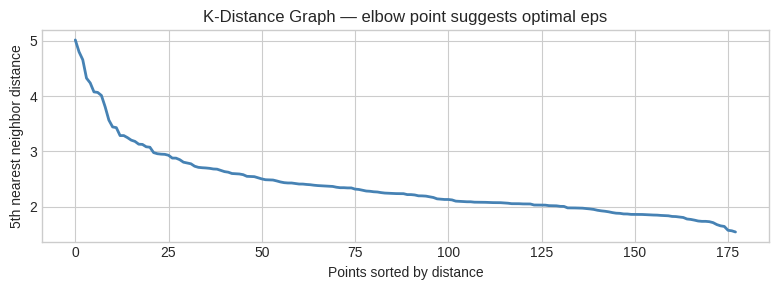

In [12]:
# ── DBSCAN full API ───────────────────────────────────────────────────────
# Important: DBSCAN is sensitive to eps and min_samples — always scale first
db = DBSCAN(
    eps=0.5,            # neighborhood radius — most sensitive parameter
    min_samples=5,      # min points to form a dense region
    metric='euclidean', # distance metric
    n_jobs=-1
)
db_labels = db.fit_predict(X_w_s)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = (db_labels == -1).sum()

print('DBSCAN on Wine dataset (scaled):')
print(f'  eps={db.eps}, min_samples={db.min_samples}')
print(f'  Clusters found:  {n_clusters}')
print(f'  Noise points:    {n_noise} ({n_noise/len(X_w_s)*100:.1f}%)')
if n_clusters > 1:
    mask = db_labels != -1
    print(f'  Silhouette:      {silhouette_score(X_w_s[mask], db_labels[mask]):.4f}')

# Finding good eps: use k-distance graph
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=5).fit(X_w_s)
distances, _ = nbrs.kneighbors(X_w_s)
k_dist = np.sort(distances[:, 4])[::-1]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(k_dist, color='steelblue', linewidth=2)
ax.set_title('K-Distance Graph — elbow point suggests optimal eps')
ax.set_xlabel('Points sorted by distance'); ax.set_ylabel('5th nearest neighbor distance')
plt.tight_layout()
plt.show()


In [13]:
# ── PCA full API ──────────────────────────────────────────────────────────
pca = PCA(
    n_components=0.95,  # keep enough components to explain 95% variance
    svd_solver='full',
    random_state=42
)
X_pca_reduced = pca.fit_transform(X_w_s)

print('PCA on Wine dataset (scaled):')
print(f'  Original dimensions:  {X_w_s.shape[1]}')
print(f'  Reduced dimensions:   {X_pca_reduced.shape[1]}')
print(f'  Total variance kept:  {pca.explained_variance_ratio_.sum():.4f}')
print(f'  Per-component EVR:    {pca.explained_variance_ratio_.round(3)}')

# PCA as preprocessing before K-Means
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_w_s)
km_pca = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_pca2)

print(f'\nK-Means on PCA-reduced data:')
print(f'  Silhouette: {silhouette_score(X_pca2, km_pca.labels_):.4f}')
print(f'  ARI:        {adjusted_rand_score(y_w, km_pca.labels_):.4f}')


PCA on Wine dataset (scaled):
  Original dimensions:  13
  Reduced dimensions:   10
  Total variance kept:  0.9617
  Per-component EVR:    [0.362 0.192 0.111 0.071 0.066 0.049 0.042 0.027 0.022 0.019]

K-Means on PCA-reduced data:
  Silhouette: 0.5611
  ARI:        0.8951


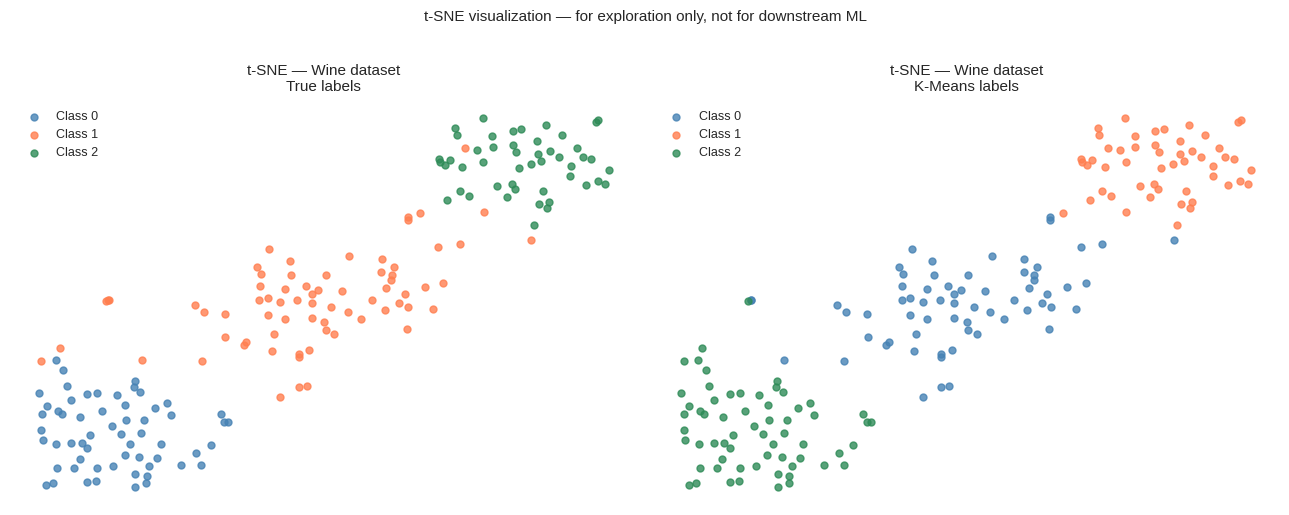

In [14]:
# ── t-SNE full API ────────────────────────────────────────────────────────
# Always apply PCA first to speed up t-SNE and reduce noise
X_pre = PCA(n_components=10, random_state=42).fit_transform(X_w_s)

tsne = TSNE(
    n_components=2,
    perplexity=30,        # ~= expected cluster size. Try 5-50.
    learning_rate='auto', # 'auto' = max(N/early_exaggeration/4, 50)
    n_iter=1000,
    random_state=42
)
X_tsne_w = tsne.fit_transform(X_pre)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, labels, title in zip(axes,
        [y_w, km.labels_],
        ['True labels', 'K-Means labels']):
    for k, color in zip(np.unique(labels), ['steelblue','coral','seagreen']):
        ax.scatter(X_tsne_w[labels==k,0], X_tsne_w[labels==k,1],
                   c=color, s=25, alpha=0.8, label=f'Class {k}')
    ax.set_title(f't-SNE — Wine dataset\n{title}', fontsize=11)
    ax.axis('off'); ax.legend(fontsize=9)

plt.suptitle('t-SNE visualization — for exploration only, not for downstream ML',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


## 8. Common Mistakes

In [15]:
# MISTAKE 1: Not scaling before K-Means or DBSCAN
X_unscaled, _ = make_blobs(n_samples=200, centers=3, random_state=42)
X_unscaled[:, 1] *= 100   # feature 2 dominates distances

labels_no_scale = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_unscaled)
sc3 = StandardScaler()
labels_scaled   = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(
    sc3.fit_transform(X_unscaled))

print(f'Without scaling: silhouette = {silhouette_score(X_unscaled, labels_no_scale):.4f}')
print(f'With    scaling: silhouette = {silhouette_score(sc3.transform(X_unscaled), labels_scaled):.4f}')
print('Always scale before K-Means and DBSCAN — they are distance-based.')


Without scaling: silhouette = 0.8490
With    scaling: silhouette = 0.8472
Always scale before K-Means and DBSCAN — they are distance-based.


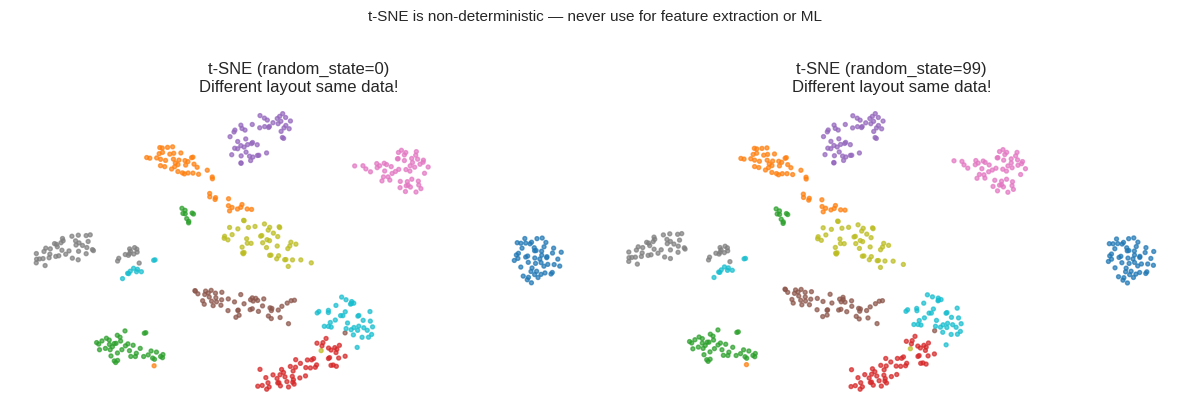

In [16]:
# MISTAKE 2: Using t-SNE output for downstream ML tasks
# t-SNE is stochastic and does not preserve global distances.
# The same data run twice gives different layouts.

X_digits, y_digits = load_digits(return_X_y=True)
X_sub = X_digits[:500]

tsne1 = TSNE(n_components=2, perplexity=30, random_state=0).fit_transform(X_sub)
tsne2 = TSNE(n_components=2, perplexity=30, random_state=99).fit_transform(X_sub)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, X_t, seed in zip(axes, [tsne1, tsne2], [0, 99]):
    ax.scatter(X_t[:,0], X_t[:,1], c=y_digits[:500], cmap='tab10', s=8, alpha=0.7)
    ax.set_title(f't-SNE (random_state={seed})\nDifferent layout same data!')
    ax.axis('off')

plt.suptitle('t-SNE is non-deterministic — never use for feature extraction or ML',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


In [17]:
# MISTAKE 3: Evaluating clustering with accuracy — wrong metric
# Cluster labels are arbitrary — cluster 0 might match true class 2.
# Use ARI (Adjusted Rand Index) or NMI which handle label permutations.

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, accuracy_score

X_ev, y_ev = make_blobs(n_samples=300, centers=3, random_state=42)
km_ev = KMeans(n_clusters=3, random_state=42, n_init=10)
pred_labels = km_ev.fit_predict(X_ev)

print('WRONG: accuracy_score(y_true, cluster_labels)')
print(f'  Accuracy = {accuracy_score(y_ev, pred_labels):.4f}  <- meaningless, labels arbitrary!\n')

print('CORRECT: use ARI or NMI')
print(f'  ARI = {adjusted_rand_score(y_ev, pred_labels):.4f}  (1.0 = perfect, 0 = random)')
print(f'  NMI = {normalized_mutual_info_score(y_ev, pred_labels):.4f}  (1.0 = perfect)')


WRONG: accuracy_score(y_true, cluster_labels)
  Accuracy = 0.3333  <- meaningless, labels arbitrary!

CORRECT: use ARI or NMI
  ARI = 1.0000  (1.0 = perfect, 0 = random)
  NMI = 1.0000  (1.0 = perfect)


## 9. Exercises

**Exercise 1:** Implement the Silhouette score from scratch for a 2-cluster result. Verify it matches sklearn on the blobs dataset.

Formula: $s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$ where $a(i)$ = mean intra-cluster distance, $b(i)$ = mean nearest-cluster distance.


In [18]:
# Your code here


In [19]:
# Solution
def silhouette_scratch(X, labels):
    n = len(X)
    unique_labels = np.unique(labels)
    scores = np.zeros(n)
    for i in range(n):
        own_cluster  = labels[i]
        own_mask     = (labels == own_cluster)
        own_mask[i]  = False
        if own_mask.sum() == 0:
            scores[i] = 0.0
            continue
        a_i = np.linalg.norm(X[i] - X[own_mask], axis=1).mean()

        other_means = []
        for lbl in unique_labels:
            if lbl == own_cluster: continue
            other_mean = np.linalg.norm(X[i] - X[labels==lbl], axis=1).mean()
            other_means.append(other_mean)
        b_i = min(other_means)

        scores[i] = (b_i - a_i) / max(a_i, b_i)
    return scores.mean()

X_sil, _ = make_blobs(n_samples=100, centers=3, random_state=42)
labels_sil = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_sil)

s_scratch = silhouette_scratch(X_sil, labels_sil)
s_sklearn = silhouette_score(X_sil, labels_sil)
print(f'Scratch  silhouette: {s_scratch:.6f}')
print(f'Sklearn  silhouette: {s_sklearn:.6f}')
print(f'Match: {np.isclose(s_scratch, s_sklearn, atol=1e-4)}')


Scratch  silhouette: 0.846988
Sklearn  silhouette: 0.846988
Match: True


**Exercise 2:** Implement PCA from scratch using SVD instead of eigendecomposition. The relationship is: $\tilde{X} = USV^T$, so the principal components are columns of $V$ and the projected data is $Z = U S$ (or equivalently $\tilde{X} V_k$). Verify your implementation matches sklearn on the wine dataset.


In [20]:
# Your code here


In [21]:
# Solution
class PCAScratchSVD:
    def __init__(self, n_components=2):
        self.n_components = n_components

    def fit_transform(self, X):
        m = X.shape[0]
        self.mean_ = X.mean(axis=0)
        Xc = X - self.mean_

        # SVD: Xc = U S V^T
        U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

        # Principal components = rows of Vt
        self.components_ = Vt[:self.n_components]

        # Explained variance
        ev = S**2 / (m - 1)
        self.explained_variance_ratio_ = ev[:self.n_components] / ev.sum()

        # Projection
        return Xc @ Vt[:self.n_components].T

wine = load_wine()
X_wine_s = StandardScaler().fit_transform(wine.data)

pca_svd = PCAScratchSVD(n_components=3)
Z_svd   = pca_svd.fit_transform(X_wine_s)

pca_sk2 = PCA(n_components=3)
Z_sk2   = pca_sk2.fit_transform(X_wine_s)

print('EVR Scratch SVD:', pca_svd.explained_variance_ratio_.round(4))
print('EVR Sklearn PCA:', pca_sk2.explained_variance_ratio_.round(4))
print('EVR match:', np.allclose(pca_svd.explained_variance_ratio_,
                                 pca_sk2.explained_variance_ratio_, atol=1e-5))


EVR Scratch SVD: [0.362  0.1921 0.1112]
EVR Sklearn PCA: [0.362  0.1921 0.1112]
EVR match: True


**Exercise 3:** Run K-Means on the wine dataset with K = 2, 3, 4, 5. For each K, compute silhouette score and ARI against true labels. Also apply PCA(2) first and repeat. Show that PCA preprocessing improves clustering quality.


In [22]:
# Your code here


In [23]:
# Solution
from sklearn.metrics import adjusted_rand_score, silhouette_score

X_w_sc = StandardScaler().fit_transform(wine.data)
X_w_pca = PCA(n_components=5, random_state=42).fit_transform(X_w_sc)

print(f'{'K':<4}  {'Sil (raw)':>12}  {'ARI (raw)':>12}  {'Sil (PCA5)':>12}  {'ARI (PCA5)':>12}')
for K in [2, 3, 4, 5]:
    km_r = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X_w_sc)
    km_p = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X_w_pca)
    sil_r = silhouette_score(X_w_sc,  km_r.labels_)
    sil_p = silhouette_score(X_w_pca, km_p.labels_)
    ari_r = adjusted_rand_score(wine.target, km_r.labels_)
    ari_p = adjusted_rand_score(wine.target, km_p.labels_)
    print(f'{K:<4}  {sil_r:12.4f}  {ari_r:12.4f}  {sil_p:12.4f}  {ari_p:12.4f}')

print('\nPCA(5) preprocessing generally improves clustering by removing noise dimensions.')


K        Sil (raw)     ARI (raw)    Sil (PCA5)    ARI (PCA5)
2           0.2593        0.3743        0.3239        0.3743
3           0.2849        0.8975        0.3691        0.8975
4           0.2602        0.7646        0.3256        0.7266
5           0.2016        0.5991        0.2645        0.5822

PCA(5) preprocessing generally improves clustering by removing noise dimensions.


---

## 👨‍💻 Author

**Himanshu Kumar**

- 🌐 GitHub: [@himanshu231204](https://github.com/himanshu231204)
- 💼 LinkedIn: [himanshu231204](https://www.linkedin.com/in/himanshu231204)
- 🐦 Twitter/X: [@himanshu231204](https://twitter.com/himanshu231204)
- 📧 Email: himanshu231204@gmail.com
